# Check out Parameter Calibration

In [1]:
import os
import numpy as np
import xarray as xr
import pandas as pd

import fates_calibration_library.utils as utils
import fates_calibration_library.emulator_functions as em
import fates_calibration_library.parameter_generation as param
from scipy.stats import gaussian_kde

import seaborn as sns

import matplotlib.pyplot as plt
import importlib

2026-01-07 11:02:38.538722: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-07 11:02:38.541033: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-07 11:02:38.570600: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-07 11:02:38.571453: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-07 11:02:41.242643: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [2]:
def plot_parameter_hists(df, default_pft, updated_vals=None):
    
    plt.figure(figsize=[18, 16])
    pars = df.columns
    for i, par in enumerate(pars):
        p = default_pft[par].values
        if updated_vals is not None:
            p_update = updated_vals[par].values
        ax = plt.subplot(7, 5, i + 1)
        ax.hist(df[par])
        ax.axvline(x=p, color='k', linestyle='-')
        if updated_vals is not None:
            ax.axvline(x=p_update, color='r', linestyle='-')
        ax.set_xlabel(par)
        ax.set_xlim(0, 1)
    plt.tight_layout()

def get_corr(sample_df, method='spearman'):
    corr = sample_df.corr(method=method)
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    corr[mask] = np.nan
    return corr

def get_final_params(var_choose, dat):
    var_median = dat[var_choose].median()
    var_diff = np.abs(dat[var_choose] - var_median)
    choose_index = np.argmin(var_diff)
    return dat.iloc[choose_index]

def subset_calibrated_ensemble(df, param_names, X_default_all, calibration_vars, imp_tol=1,
                              plot_output=False):
    
    fixed_indices = np.where(~np.isin(param_names.values, df.columns.values))[0]
    
    sample = np.asarray(df)
    result = np.array([
        em.get_full_array(sample[i], fixed_indices, X_default_all)
        for i in range(sample.shape[0])
    ])

    for i, variable in enumerate(calibration_vars):
        y_pred, y_var = emulators[i](result)
        implaus = em.implausibility_metric(y_pred.numpy().flatten(), targets[i],
                                           y_var.numpy().flatten(), sds[0]**2)
        df[f"{variable}_implaus"] = implaus
        if plot_output:
            em.plot_implausibility_histogram(implaus, tol=imp_tol)
            em.plot_emulated_sample(y_pred.numpy().flatten(), targets[i], sds[i],
                                    pft_id, calibration_vars[i],
                                    obs_config[variable]['global_units'])

    col_list = [f"{f}_implaus" for f in calibration_vars]
    df_sub = em.subset_sample(df, col_list, imp_tol)
    df_sub['sum_implaus'] = em.calculate_implaus_sum(df_sub, col_list)

    df_out = df_sub.where(df_sub['sum_implaus'] < imp_tol)
    df_out = df_out.dropna()
    df_out = df_out.drop(columns=np.append('sum_implaus', col_list))

    return df_out

def marginal_mode_kde(data_1d):
    kde = gaussian_kde(data_1d)
    # Define a fine grid over the parameter range
    grid = np.linspace(data_1d.min(), data_1d.max(), 1000)
    kde_values = kde(grid)
    mode_index = np.argmax(kde_values)
    return grid[mode_index]

def get_rescaled(params, final_pars):

    all_rescaled = {}
    for parameter in params:
        val = final_pars[parameter].values
        
        if parameter == 'smpsc_delta':
            actual_param_name = param.PARAM_INFO[parameter]['actual_param']
        elif parameter == 'fates_stoich_nitr_1':
            actual_param_name = param.PARAM_INFO[parameter]['actual_param']
        else:
            actual_param_name = parameter
    
        if parameter == 'fates_stoich_nitr_1':
            default_value = default_param[actual_param_name].isel(fates_plant_organs=0)
        else: 
            default_value = default_param[actual_param_name]
            
        sub = main_param[main_param.fates_parameter_name == parameter]
        
        # get min and max parameter values
        change_str_min = str(sub["param_min"].values[0])
        change_str_max = str(sub["param_max"].values[0])
        
        min_value = param.get_param_value(
            change_str_min, default_value, param_dat, parameter, "param_min"
        )
        max_value = param.get_param_value(
            change_str_max, default_value, param_dat, parameter, "param_max"
        )
        unnormalized = param.unnormalize(val, min_value, max_value)
        if unnormalized.size != 1:
            norm_values = unnormalized.flatten()[pft-1]
        else:
            norm_values = unnormalized
        all_rescaled[parameter] = norm_values
    return all_rescaled

def summarize_clusters(best_params, model, labels, centers):
    summaries = []
    for cluster in range(len(centers)):
        indices = np.where(labels == cluster)[0]
        cluster_samples = best_params.iloc[indices]
        cluster_scaled = X_scaled[indices]

        mean = cluster_samples.mean()
        std = cluster_samples.std()
        size = len(cluster_samples)

        distances = cdist(cluster_scaled, [centers[cluster]])
        nearest_idx = indices[np.argmin(distances)]
        representative_sample = best_params.iloc[nearest_idx]

        summary = {
            'cluster': cluster,
            'size': size,
            'mean': mean,
            'std': std,
            'representative_sample_index': nearest_idx,
            'representative_sample': representative_sample
        }
        summaries.append(summary)
    return summaries

def plot_pca_clusters(df, label_column, title):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="PC1", y="PC2", hue=label_column, palette="tab10", alpha=0.7)
    plt.title(title)
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()
    
def print_summary(summary):
    print(f"\nCluster {summary['cluster']} (n={summary['size']})")
    print("Mean values:\n", summary['mean'])
    print("Representative sample:\n", summary['representative_sample'])

def plot_parameter_distributions_density(df, labels):
    df_clustered = df.copy()
    df_clustered['cluster'] = labels
    melted = df_clustered.melt(id_vars='cluster', var_name='parameter', value_name='value')
    plt.figure(figsize=(10,10))
    g = sns.FacetGrid(melted, col='parameter', col_wrap=4, hue='cluster', sharex=False, sharey=False)
    g.map(sns.kdeplot, 'value', fill=True, alpha=0.5).add_legend()
    g.fig.subplots_adjust(top=0.9)
    plt.show()

def print_correlation(parameter_corr):
    return parameter_corr.style.background_gradient(cmap='coolwarm', axis=None, vmin=-1, vmax=1).highlight_null(color='#f1f1f1').format(precision=2)

## Set Up
Load files, set up ensemble information

In [3]:
# directories
mesh_dir = '/glade/work/afoster/FATES_calibration/mesh_files'
emulator_dir = '/glade/work/afoster/FATES_calibration/emulators'
fig_dir = '/glade/work/afoster/FATES_calibration/figures'
param_dir = '/glade/work/afoster/FATES_calibration/parameter_files'
out_dir = '/glade/work/afoster/FATES_calibration/parameter_outputs'

# default parameter file
default_param = xr.open_dataset(os.path.join(param_dir, 
                                             'fates_params_default_sci.1.85.1_api.40.0.0_crops.nc'))
all_pfts = [str(pft).replace("b'", "").replace("'", "").strip() for pft in default_param.fates_pftname.values]

# normalized values for parameters
default_norm = pd.read_csv(os.path.join(param_dir, 'normalized_parameters.csv'), index_col=[0])

# information about variables
obs_config_file = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/ilamb_conversion.yaml'
obs_config = utils.get_config_file(obs_config_file)

# PFT ids
pft_id_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/fates_pft_ids.yaml'
pft_ids = utils.get_config_file(pft_id_config)

# calibration vars
calib_vars_config = '/glade/work/afoster/FATES_calibration/emulator_configs/calibration_vars.yaml'
calib_vars = utils.get_config_file(calib_vars_config)

# parameter calibration information
param_list_name = "param_list_sci.1.85.1_api.40.0.0.xls"
param_list_file = os.path.join(param_dir, param_list_name)
param_dat = param.get_param_dictionary(param_list_file)
main_param = param_dat["main"]

In [4]:
# information about each ensemble
ens_dict = {'dompft':
            {'mesh_file': os.path.join(mesh_dir, 'dominant_grid_mesh.nc'),
             'land_mask_file': os.path.join(mesh_dir, 'dominant_grid.nc'),
             'lhc_key_file': os.path.join(param_dir, 'fates_lh', 'fates_lh_key.csv'),
             'pfts': [1, 2, 3, 12, 13],
             'obs_df': os.path.join(mesh_dir, 'dominant_grid.csv'),
            },
            'codompft':
            {'mesh_file': os.path.join(mesh_dir, 'co-dominant_grid_mesh.nc'),
             'land_mask_file': os.path.join(mesh_dir, 'co-dominant_grid.nc'),
             'lhc_key_file': os.path.join(param_dir, 'fates_lh_codom', 'fates_lh_key.csv'),
             'pfts': [4, 6, 11, 14],
             'obs_df': os.path.join(mesh_dir, 'co-dominant_grid.csv'),
            }
           }

In [5]:
# choose ensemble
ensemble = 'dompft'

## Ensemble Investigation

### Load data
Load Latin Hypercube key and observations

In [6]:
# load latin hypercube key
lhc_key = pd.read_csv(ens_dict[ensemble]['lhc_key_file'], index_col=[0])
lhc_key = lhc_key.drop(columns=['ensemble'])
param_names = lhc_key.columns
num_params = len(param_names)

# load observations
obs = pd.read_csv(ens_dict[ensemble]['obs_df'], index_col=[0])

### PFT Investigation

In [52]:
# choose pft
pft = 13
pft_name = all_pfts[pft-1]
pft_id = pft_ids[pft_name]
calibration_vars = calib_vars[pft_id]

Load emulators and subset observations

In [53]:
# get observations for this pft
obs_pft = obs[obs.pft == pft_name]

if pft_id != 'BEET':
    obs_pft = obs_pft[obs_pft.land_frac > 0.99]
if pft_id != 'AC3G':
    obs_pft = obs_pft[obs_pft.pct_lake < 30]

# get default values for this pft
X_default_all = em.get_default_pft_values(default_norm, pft)

# load emulators, targets, and sds
emulators, targets, sds = em.prep_calibration_data(obs_pft, calibration_vars,
                                                   obs_config, emulator_dir,
                                                   pft_name, pft_id)

### Calibrated parameter ensemble

In [54]:
# get calibrated parameter distribution
calib_df = em.get_calibrated_distribution(os.path.join(out_dir, f"{pft}_outputs"))

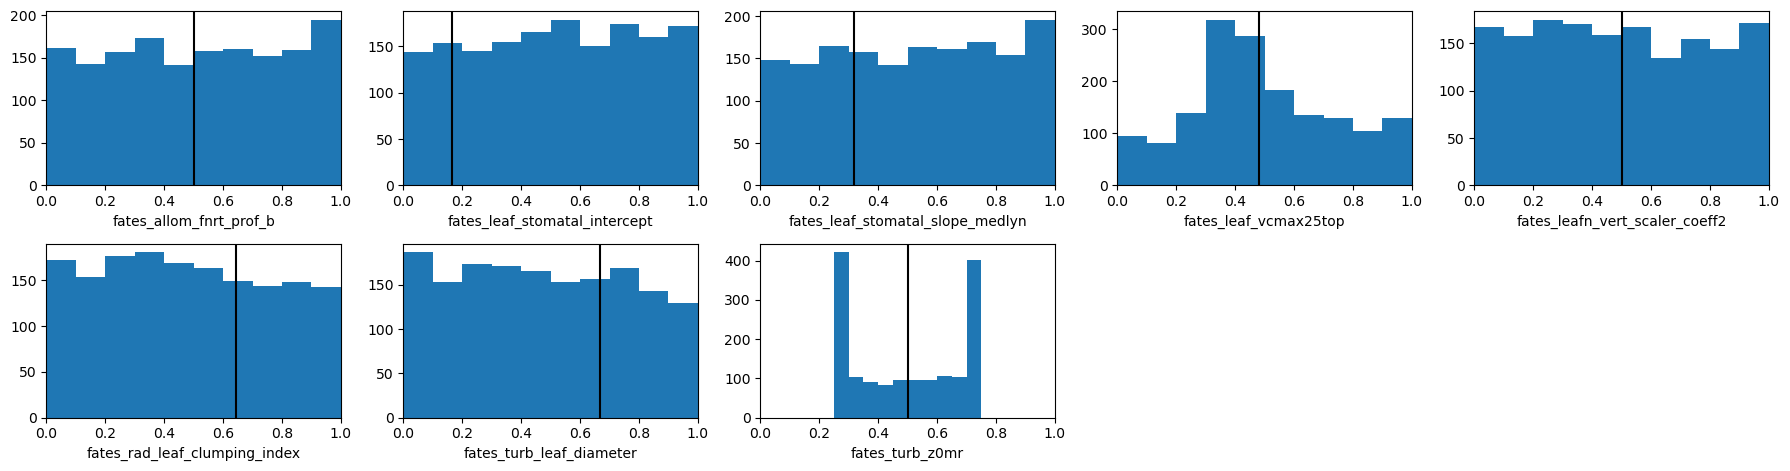

In [55]:
plot_parameter_hists(calib_df, default_norm[default_norm.pft == pft])

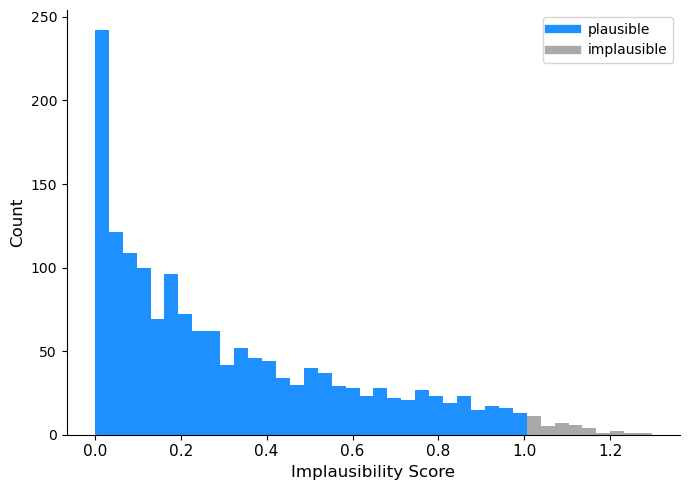

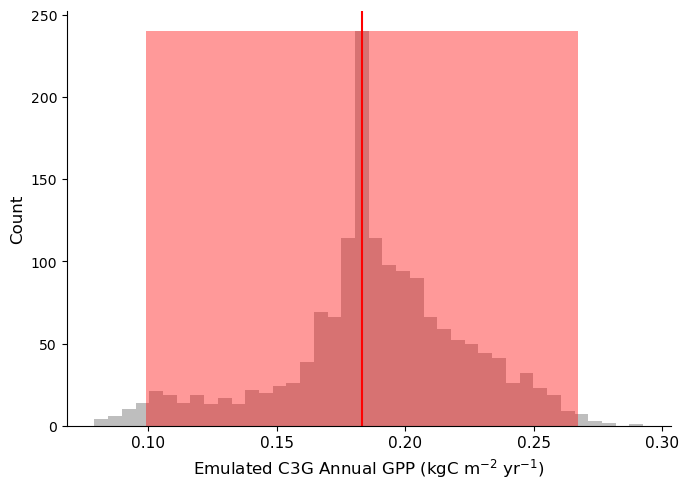

In [56]:
# subset based on emulators
df_subset = subset_calibrated_ensemble(calib_df, param_names, X_default_all,
                                       calibration_vars, plot_output=True, imp_tol=1)

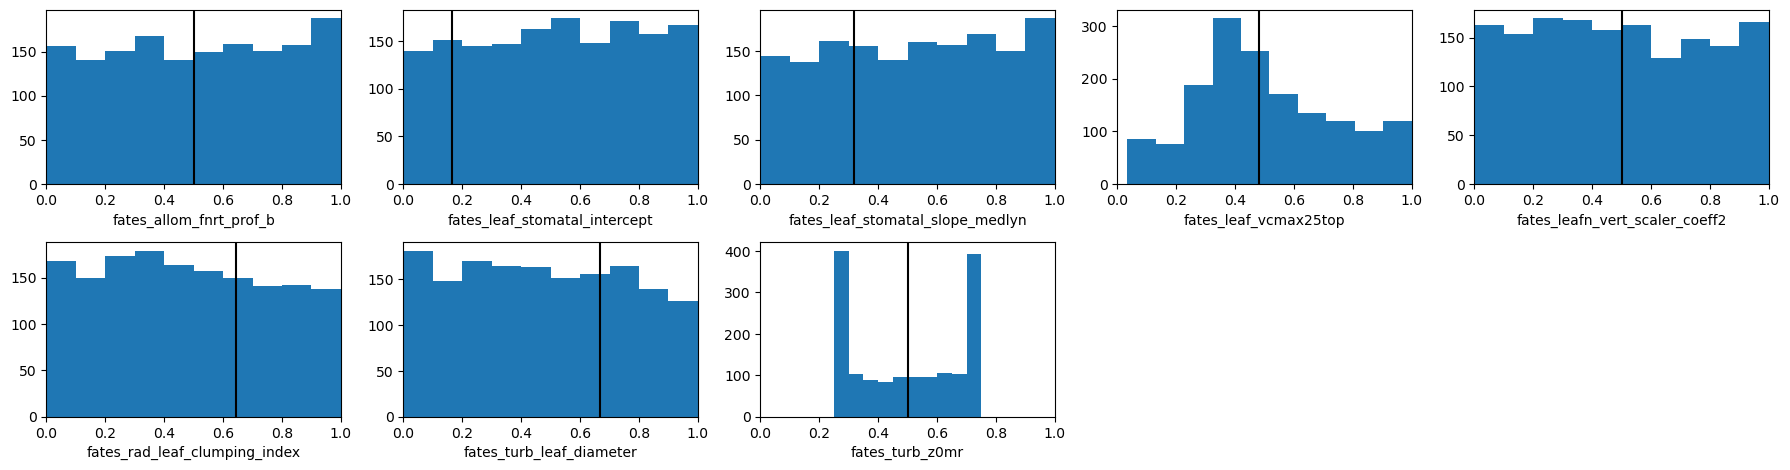

In [57]:
plot_parameter_hists(df_subset, default_norm[default_norm.pft == pft])

### Posterior summary statistics

#### Marginal mean, median, mode

In [58]:
marginal_mean = df_subset.mean(axis=0)
marginal_median = df_subset.median(axis=0)

marginal_modes = {}
for parameter in df_subset.columns:
    marginal_modes[parameter] = marginal_mode_kde(df_subset[parameter].values)

summary_stats = pd.DataFrame({'parameter': marginal_mean.index,
                              'marginal_mean': marginal_mean.values,
                              'marginal_median': marginal_median.values,
                              'marginal_mode': marginal_modes.values()}).melt(id_vars=['parameter'])

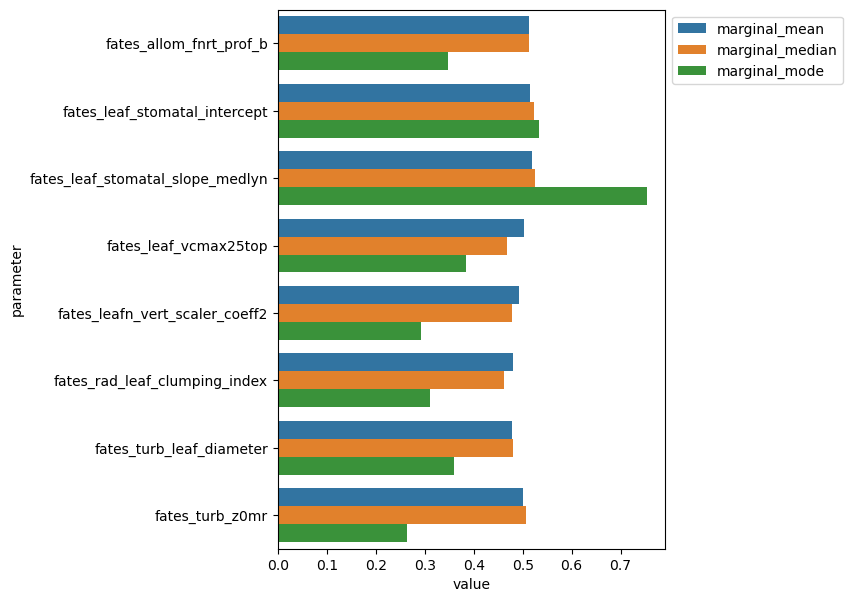

In [59]:
plt.figure(figsize=(5,7))
sns.barplot(data=summary_stats, y='parameter',
            x='value', hue='variable')
plt.legend(bbox_to_anchor=(1.0, 1.0));

### Correlations

<Axes: >

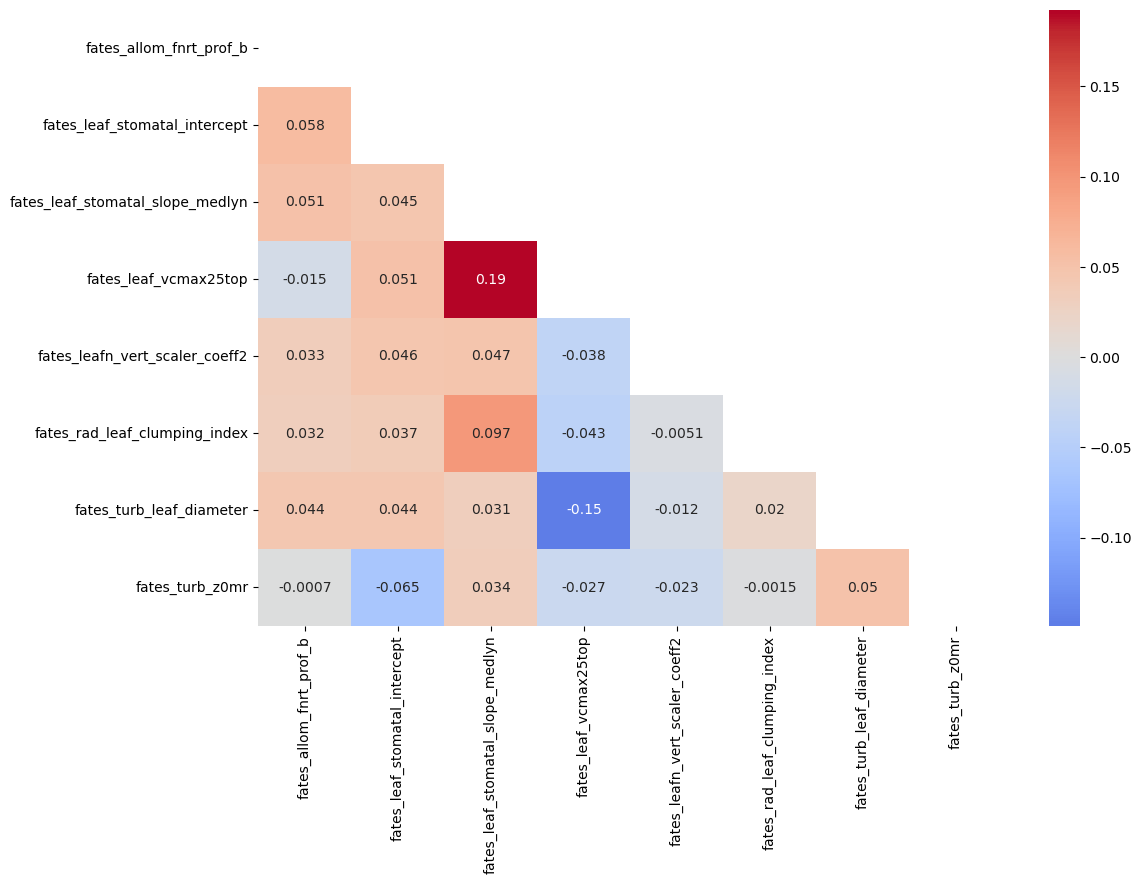

In [60]:
parameter_corr = get_corr(df_subset)
plt.figure(figsize=(12, 8))
sns.heatmap(parameter_corr, annot=True, cmap='coolwarm', center=0)

In [62]:
pars_to_choose = ['fates_leaf_vcmax25top',
                  'fates_leaf_slatop',
                  'fates_leaf_stomatal_intercept',
                  'fates_leaf_stomatal_slope_medlyn']

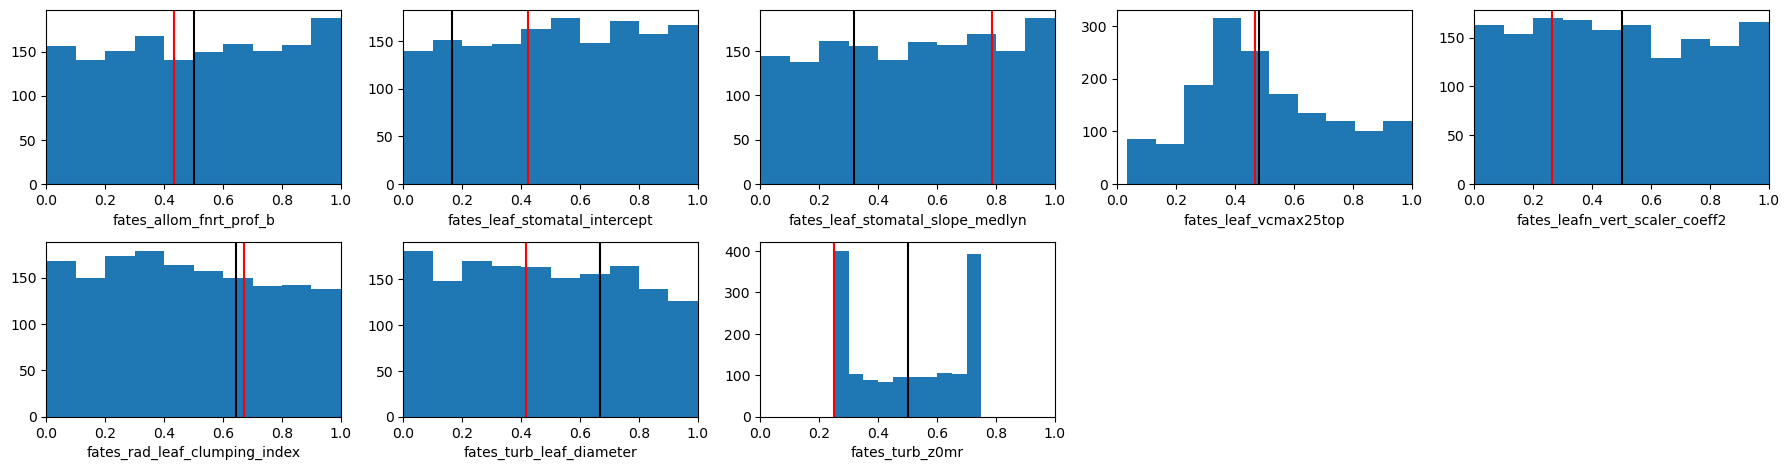

In [63]:
final_pars = get_final_params(pars_to_choose[0], df_subset).to_frame().T
plot_parameter_hists(df_subset, default_norm[default_norm.pft == pft],
                     final_pars)

In [50]:
rescaled_values = get_rescaled(df_subset.columns, final_pars)
df = pd.DataFrame({'parameter_value': rescaled_values})
df['parameter_name'] = df.index
df['PFT'] = pft_id
df = df.reset_index()
# df.to_csv(os.path.join(out_dir, f"{pft_id}_final_param_choice.csv"))

In [ ]:
pfts = [1, 2, 3, 12, 13]
pft_names = [all_pfts[pft-1] for pft in pfts]
pft_codes = [pft_ids[pft_name] for pft_name in pft_names]

In [ ]:
all_dfs = []
for pft in pfts:
    pft_name = all_pfts[pft-1]
    pft_code = pft_ids[pft_name]
    df = pd.read_csv(os.path.join(out_dir, f"{pft_code}_final_param_choice.csv"))
    df = df[['parameter_value', 'parameter_name', 'PFT']]
    df['pft_id'] = pft
    all_dfs.append(df)
df = pd.concat(all_dfs)

In [ ]:
df.to_csv(os.path.join(out_dir, 'all_dom_pfts_update.csv'))

In [ ]:
out_dir